In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pyshtools as pysh
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
import os 
from meshplot import plot, subplot 
import anndata as ad
import pandas as pd

import igl 
from scipy.sparse.linalg import eigsh
from tqdm import tqdm

In [2]:
from src import utils 
from src import meshharm
from src.fatemarkers import FateMarkers

In [3]:
path = 'Data/20250714/fractal_output/'

timepoints = ['day1p5', 'day2', 'day2p5', 'day3', 'day3p5', 'day4', 'day4p5', 'day4p5-more']

zarr_names = {
        'day1p5': 'r0.zarr',
        'day2':'r0.zarr',
        'day2p5':'r0.zarr',
        'day3':'r0.zarr',
        'day3p5':'r0.zarr',
        'day4':'r0.zarr',
        'day4p5':'r0.zarr',
        'day4p5-more':'r0.zarr',
}


wells = {
    'day1p5': ['A01', 'A02', 'A03', 'A04', 'A05', 'A06'],
    'day2': ['A01', 'A02', 'A03', 'A04', 'A05', 'A06'],
    'day2p5': ['A01', 'A02', 'A03', 'A04', 'A05', 'A06'],
    'day3': ['A01', 'A02', 'A03', 'A04', 'A05', 'A06', 'B02', 'B03'],
    'day3p5': ['A01', 'A02', 'A03', 'A04', 'B03'],
    'day4': ['A02', 'A03', 'A04', 'A05', 'A06', 'B01', 'B02'],
    'day4p5': ['A06', 'B06'],
    'day4p5-more': ['C01', 'C02', 'C03', 'C04', 'C05', 'C06'],
}

rounds = {
    'day1p5': ['0_fused_zillum'],
    'day2': ['0_fused_zillum'],
    'day2p5': ['0_fused_zillum'],
    'day3': ['0_fused_zillum'],
    'day3p5': ['0_fused_zillum'],
    'day4': ['0_fused_zillum'],
    'day4p5': ['0_fused_zillum'],
    'day4p5-more': ['0_fused_zillum'],
}
times_dic = {
    '1p5': 1.5,
    '2': 2,
    '2p5': 2.5,
    '3': 3,
    '3p5': 3.5,
    '4': 4,
    '4p5': 4.5,
    '4p5-more': 4.5
}

In [4]:
def load(save_path, ts): 
    m = FateMarkers()
    m.load_results(save_path)
    frac_diff = m.compute_recon_quality()
    coeffs_hks = m.compute_hks_for_new_times(new_ts=ts)
    spectrums = np.sqrt(m.compute_spectrum(coeffs_hks))/m.mass_matrix.diagonal().sum() 
    return spectrums, frac_diff

In [6]:
spectrums = [] 
times = [] 
fracs = [] 
ids = [] 

ts = np.exp(2*np.linspace(0, np.log(10), 100))
for timepoint in timepoints:
    zarr_name = zarr_names[timepoint]
    for well_name in wells[timepoint]:
        round_name = rounds[timepoint][0]

        file_path = f"{path}{timepoint}/{zarr_name}/{well_name[0]}/{well_name[1:]}/{round_name}/"
        labels = np.load(file_path + 'good_labels.npy').astype('int')
        print(file_path) 
        for label in tqdm(labels[::10]):
            save_path = f"{file_path}/fm_data/{label}"
            if os.path.exists(save_path + '_coeffs.npz'):
                coor_spectrum, frac = load(save_path, ts=ts)
                spectrums.append(coor_spectrum)
                times.append(timepoint[3:6])
                fracs.append(frac)
                ids.append(f"{timepoint}_{well_name}_{label}")

Data/20250714/fractal_output/day1p5/r0.zarr/A/01/0_fused_zillum/


100%|██████████| 12/12 [00:04<00:00,  2.79it/s]


Data/20250714/fractal_output/day1p5/r0.zarr/A/02/0_fused_zillum/


100%|██████████| 6/6 [00:02<00:00,  2.58it/s]


Data/20250714/fractal_output/day1p5/r0.zarr/A/03/0_fused_zillum/


...

100%|██████████| 10/10 [00:02<00:00,  4.82it/s]


Data/20250714/fractal_output/day4p5-more/r0.zarr/C/05/0_fused_zillum/


100%|██████████| 11/11 [00:02<00:00,  4.93it/s]


Data/20250714/fractal_output/day4p5-more/r0.zarr/C/06/0_fused_zillum/


100%|██████████| 14/14 [00:02<00:00,  4.75it/s]


In [46]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import MDS, TSNE
import warnings

class SpectralFeatureExtractor:
    """
    A class for extracting features from spectral data through normalization,
    bag-of-features representation, and dimensionality reduction.
    
    Expected input shape: (n_samples, dim_t_space, n_modes)
    """
    
    def __init__(self, n_t_clusters=8, n_spectrum_clusters=5, random_state=42):
        """
        Initialize the SpectralFeatureExtractor.
        
        Parameters:
        -----------
        n_t_clusters : int, default=8
            Number of clusters for t-space bag-of-features
        n_spectrum_clusters : int, default=5
            Number of clusters for spectrum-level clustering
        random_state : int, default=42
            Random state for reproducibility
        """
        self.n_t_clusters = n_t_clusters
        self.n_spectrum_clusters = n_spectrum_clusters
        self.random_state = random_state
        
        # Initialize components
        self.scaler = StandardScaler()
        self.lmax = 0 
        self.t_kmeans = None
        self.spectrum_kmeans = None
        self.dim_reducer = None
        
        # Store processed data
        self.rescaled_spectrums = None
        self.t_space_vectors = None
        self.t_vocab = None
        self.encoding = None
        self.encoding_reshaped = None
        self.sigma = None
        
    def preprocess(self, spectrums):
        """
        Normalize the input spectrums using sklearn Normalizer.
        
        Parameters:
        -----------
        spectrums : np.ndarray
            Input data with shape (n_samples, dim_t_space, n_modes)
        skip_mode_0 : bool, default=True
            Whether to skip mode 0 (as in original code with i > 0 condition)
            
        Returns:
        --------
        np.ndarray
            Normalized spectrums with same shape as input
        """
        self.lmax = spectrums.shape[1] 
        self.dim_t_space = spectrums.shape[-1] 

        self.rescaled_spectrums = np.log(spectrums+1e-10) 

        return self.rescaled_spectrums
    
    def create_bag_of_features(self, rescaled_spectrums=None):
        """
        Create bag-of-features representation using K-means clustering on t-space vectors.
        
        Parameters:
        -----------
        rescaled_spectrums : np.ndarray, optional
            Preprocessed spectrums. If None, uses stored rescaled_spectrums
            
        Returns:
        --------
        tuple
            (encoding_reshaped, t_vocab) - bag-of-features encoding and vocabulary
        """
        if rescaled_spectrums is None:
            rescaled_spectrums = self.rescaled_spectrums
        
        # Reshape for t-space clustering: swap axes and flatten
        # Original: (n_samples, dim_t_space, n_modes) -> (n_samples, n_modes, dim_t_space) -> (n_samples*n_modes, dim_t_space)
        self.t_space_vectors = rescaled_spectrums.reshape(-1, self.dim_t_space)
        self.t_space_vectors = self.scaler.fit_transform(self.t_space_vectors)

        # Fit K-means on t-space vectors
        self.t_kmeans = KMeans(n_clusters=self.n_t_clusters, random_state=self.random_state)
        self.t_kmeans.fit(self.t_space_vectors)
        self.t_vocab = self.t_kmeans.cluster_centers_
        
        # Get distances and create soft assignments
        dist = self.t_kmeans.transform(self.t_space_vectors)
        cluster_id = np.argmin(dist, axis=1)
        
        # Compute typical cluster size (sigma)
        self.sigma = np.mean(dist[np.arange(dist.shape[0]), cluster_id])
        
        # Create soft encoding using Gaussian kernel
        self.encoding = np.exp(-dist**2 / (2 * self.sigma**2))
        
        return self.encoding, self.t_vocab, cluster_id 
    
    def fit_spectrum_clusters(self):
        """
        Fit K-means clustering on the bag-of-features representations.
        
        Parameters:
        -----------
        encoding_reshaped : np.ndarray, optional
            Bag-of-features encoding. If None, uses stored encoding_reshaped
            
        Returns:
        --------
        np.ndarray
            Cluster assignments for each spectrum
        """
        encoding_reshaped = self.encoding.reshape(-1, int(self.lmax*self.n_t_clusters))
    
        # Fit K-means on spectrum-level features
        self.spectrum_kmeans = KMeans(n_clusters=self.n_spectrum_clusters, random_state=self.random_state)
        self.spectrum_kmeans.fit(encoding_reshaped)
        
        # Get cluster assignments
        cluster_id = np.argmin(self.spectrum_kmeans.transform(encoding_reshaped), axis=1)

        return encoding_reshaped, self.spectrum_kmeans.cluster_centers_, cluster_id

    def reduce_dimensions(self, data, clustering_centres, method='pca', n_components=2, **kwargs):
        """
        Apply dimensionality reduction for visualization.
        
        Parameters:
        -----------
        data: np.ndarray
            A high dimensional data to be reduced.
        clustering_centres: np.ndarray
            The cluster centers to be reduced.
        method : str, default='pca'
            Dimensionality reduction method ('pca', 'tsne', 'mds', 'umap')
        n_components : int, default=2
            Number of dimensions in reduced space
        **kwargs : dict
            Additional parameters for the dimensionality reduction method
            
        Returns:
        --------
        tuple
            (spectrum_reduced, cluster_centers_reduced) - reduced representations
        """
        
        # Set up dimensionality reduction method
        if method.lower() == 'pca':
            self.dim_reducer = PCA(n_components=n_components, random_state=self.random_state, **kwargs)
            self.dim_reducer.fit(data)
            spectrum_reduced = self.dim_reducer.transform(data)
            cluster_centers_reduced = self.dim_reducer.transform(clustering_centres)

        elif method.lower() == 'tsne':
            # For t-SNE, fit on combined data as in original code
            default_kwargs = {'perplexity': 30, 'random_state': self.random_state}
            default_kwargs.update(kwargs)
            
            self.dim_reducer = TSNE(n_components=n_components, **default_kwargs)
            to_fit = np.concatenate((data, clustering_centres), axis=0)
            reduced_combined = self.dim_reducer.fit_transform(to_fit)

            spectrum_reduced = reduced_combined[:data.shape[0], :]
            cluster_centers_reduced = reduced_combined[data.shape[0]:, :]

        elif method.lower() == 'mds':
            default_kwargs = {'random_state': self.random_state}
            default_kwargs.update(kwargs)
            
            self.dim_reducer = MDS(n_components=n_components, **default_kwargs)
            to_fit = np.concatenate((data, clustering_centres), axis=0)
            reduced_combined = self.dim_reducer.fit_transform(to_fit)
            
            spectrum_reduced = reduced_combined[:data.shape[0], :]
            cluster_centers_reduced = reduced_combined[data.shape[0]:, :]

        elif method.lower() == 'umap':
            try:
                import umap
                default_kwargs = {'random_state': self.random_state}
                default_kwargs.update(kwargs)
                
                self.dim_reducer = umap.UMAP(n_components=n_components, **default_kwargs)
                self.dim_reducer.fit(data)
                spectrum_reduced = self.dim_reducer.transform(data)
                cluster_centers_reduced = self.dim_reducer.transform(clustering_centres)

            except ImportError:
                raise ImportError("UMAP not installed. Please install with: pip install umap-learn")
                
        else:
            raise ValueError(f"Unknown method: {method}. Choose from 'pca', 'tsne', 'mds', 'umap'")
        
        return spectrum_reduced, cluster_centers_reduced
    
    def reverse_transform(self, encoding_reshaped, method='nearest_sample'):
        """
        Reconstruct original spectrums from bag-of-features encoding.
        
        Parameters:
        -----------
        encoding_reshaped : np.ndarray
            Bag-of-features encoding with shape (n_samples, n_modes*n_clusters)
        original_shape : tuple
            Original shape (n_samples, dim_t_space, n_modes) of the input filtered_spectrums
            
        Returns:
        --------
        np.ndarray
            Reconstructed spectrums with original shape (note: these are normalized versions)
        """
        
        # Step 1: Reshape encoding back to (n_samples*n_modes, n_clusters)
        encoding = encoding_reshaped.reshape(-1, self.n_t_clusters)
        
        # Step 2: Reconstruct t-space vectors
        t_space_reconstructed = np.zeros((encoding.shape[0], self.dim_t_space))

        if method == 'nearest': 
            recon_func = lambda x: self.t_vocab[np.argmax(x)]
        elif method == 'weighted':
            recon_func = self._weighted_recon
        elif method == 'nearest_sample':
            recon_func = self._nearest_sample_recon
        elif method == 'sphere_intersection':
            recon_func = self._sphere_intersection
        else: 
            raise ValueError(f"Unknown method: {method}. Choose from 'weighted', 'nearest', 'gaussian_inverse', 'nearest_sample', 'sphere_intersection'")

        for i in range(encoding.shape[0]):
            t_space_reconstructed[i] = recon_func(encoding[i])
        
        # Step 3: Reshape back to (n_samples, n_modes, dim_t_space) then swap axes
        t_space_reconstructed = self.scaler.inverse_transform(t_space_reconstructed)
        t_space_reshaped = t_space_reconstructed.reshape(-1, self.lmax, self.dim_t_space)
        return t_space_reshaped

    def _nearest_sample_recon(self, encoding_vector):
        # Find nearest sample in encoding space and use its original t-space vector
        distances_to_samples = np.linalg.norm(self.encoding - encoding_vector, axis=1)
        nearest_sample_idx = np.argmin(distances_to_samples)
        return self.t_space_vectors[nearest_sample_idx]

    def _weighted_recon(self, encoding_vector):
        weights = encoding_vector / (np.sum(encoding_vector) + 1e-8)
        return np.sum(weights[:, np.newaxis] * self.t_vocab, axis=0)

    def _sphere_intersection(self, encoding_vector): 
        # Convert encoding back to exact distances
        safe_encoding = np.maximum(encoding_vector, 1e-10)
        distances = self.sigma * np.sqrt(-2 * np.log(safe_encoding))
        
        # Solve exact sphere intersection problem
        # ||x - c_j||^2 = d_j^2 for all j
        # Since original point existed, this system has a solution
        
        if self.n_t_clusters > 1:
            # Use first cluster as reference point
            # ||x - c_0||^2 = d_0^2
            # ||x - c_j||^2 = d_j^2  for j = 1,2,...,k-1
            # 
            # Subtracting first equation from others:
            # ||x - c_j||^2 - ||x - c_0||^2 = d_j^2 - d_0^2
            # (x^T x - 2c_j^T x + c_j^T c_j) - (x^T x - 2c_0^T x + c_0^T c_0) = d_j^2 - d_0^2
            # 2(c_0 - c_j)^T x = c_j^T c_j - c_0^T c_0 - d_j^2 + d_0^2
            
            A = 2 * (self.t_vocab[0] - self.t_vocab[1:])  # (k-1, d) matrix
            b = (np.sum(self.t_vocab[1:]**2, axis=1) - np.sum(self.t_vocab[0]**2) - 
                    distances[1:]**2 + distances[0]**2)
            
            # Solve the linear system Ax = b
            if A.shape[0] >= A.shape[1]:  # More equations than unknowns
                x, _, _, _ = np.linalg.lstsq(A, b, rcond=None)
            else:  # Under-determined, use minimum norm solution
                x = np.linalg.pinv(A) @ b
            
            reconstructed_vector = x
        else:
            # Single cluster case - point is on sphere around cluster center
            # Choose arbitrary direction (could be random)
            direction = np.random.randn(self.dim_t_space)
            direction = direction / np.linalg.norm(direction)
            reconstructed_vector = self.t_vocab[0] + distances[0] * direction

        return reconstructed_vector

    
    def fit_transform(self, spectrums, dim_method='pca', n_components=2, skip_mode_0=True, **kwargs):
        """
        Complete pipeline: preprocess -> bag-of-features -> clustering -> dimensionality reduction.
        
        Parameters:
        -----------
        spectrums : np.ndarray
            Input data with shape (n_samples, dim_t_space, n_modes)
        dim_method : str, default='pca'
            Dimensionality reduction method
        n_components : int, default=2
            Number of dimensions for reduction
        skip_mode_0 : bool, default=True
            Whether to skip mode 0 in preprocessing
        **kwargs : dict
            Additional parameters for dimensionality reduction
            
        Returns:
        --------
        dict
            Dictionary containing:
            - 'spectrum_reduced': reduced spectrum representations
            - 'cluster_centers_reduced': reduced cluster center representations  
            - 'cluster_assignments': cluster assignments for each spectrum
            - 'encoding': bag-of-features encoding
            - 'preprocessed': preprocessed spectrums
        """
        # Run complete pipeline
        rescaled = self.preprocess(spectrums)
        encoding, vocab = self.create_bag_of_features(rescaled)
        cluster_assignments = self.fit_spectrum_clusters(encoding)
        spectrum_reduced, cluster_centers_reduced = self.reduce_dimensions(
            method=dim_method, n_components=n_components, encoding_reshaped=encoding, **kwargs
        )
        
        return {
            'spectrum_reduced': spectrum_reduced,
            'cluster_centers_reduced': cluster_centers_reduced,
            'cluster_assignments': cluster_assignments,
            'encoding': encoding,
            'preprocessed': rescaled,
            't_vocab': vocab
        }

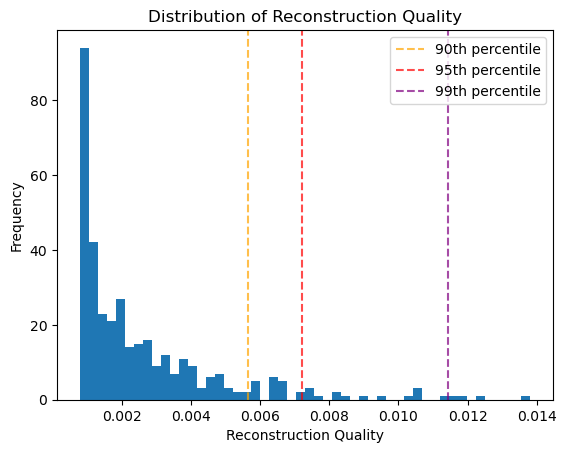

In [8]:
plt.hist(fracs, bins=50)
plt.axvline(np.percentile(fracs, 90), color='orange', linestyle='--', alpha=0.7, label='90th percentile')
plt.axvline(np.percentile(fracs, 95), color='red', linestyle='--', alpha=0.7, label='95th percentile')
plt.axvline(np.percentile(fracs, 99), color='purple', linestyle='--', alpha=0.7, label='99th percentile')
plt.legend()
plt.xlabel('Reconstruction Quality')
plt.ylabel('Frequency')
plt.title('Distribution of Reconstruction Quality')
plt.show()

In [61]:
threshold = np.percentile(fracs, 95)
recon_mask = np.array(fracs) < threshold

filtered_times = np.array(times)[recon_mask]
filtered_spectrums = np.array(spectrums)[recon_mask]
filtered_ids = np.array(ids)[recon_mask]

In [47]:
processor = SpectralFeatureExtractor() 
rescaled_spectrums = processor.preprocess(filtered_spectrums)

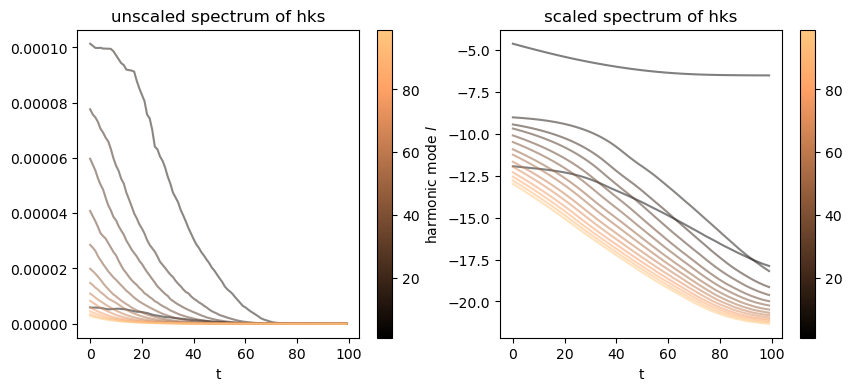

In [48]:
from sklearn.preprocessing import Normalizer

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)    


# Get the copper colormap
copper_cmap = plt.get_cmap('copper')
n_components = filtered_spectrums.shape[1] - 1

for i in range(0, filtered_spectrums.shape[1]): 
    color = copper_cmap((i-1) / (n_components-1))  # Normalize i to [0,1] range
    if i > 0: 
        axes[0].plot(np.median(filtered_spectrums[:, i, :], axis=0), color=color, alpha=0.5)
    axes[1].plot(np.mean(rescaled_spectrums[:, i, :], axis=0), color=color, alpha=0.5)

axes[0].set_xlabel('t')
axes[1].set_xlabel('t')
axes[0].set_title('unscaled spectrum of hks')
axes[1].set_title('scaled spectrum of hks')

# Add colorbar
sm = plt.cm.ScalarMappable(cmap=copper_cmap, norm=plt.Normalize(vmin=1, vmax=filtered_spectrums.shape[-1]-1))
cbar = plt.colorbar(sm, ax=axes[1])
cbar = plt.colorbar(sm, ax=axes[0])
cbar.set_label(r'harmonic mode $l$')

plt.show() 


In [ ]:
processor.n_t_clusters = 6 
encoding, vocab, t_space_cluster_id = processor.create_bag_of_features()

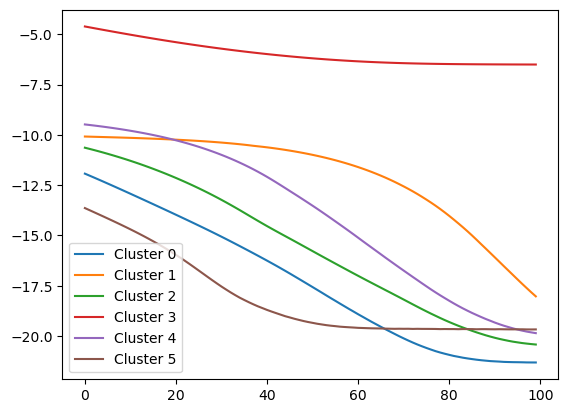

In [69]:
vocab_og = processor.scaler.inverse_transform(vocab)
for i, v in enumerate(vocab_og ): 
    plt.plot(v, label=f'Cluster {i}')
plt.legend() 
plt.show() 

In [70]:
t_space_reduced, cluster_centers_reduced = processor.reduce_dimensions(processor.t_space_vectors, vocab, method='TSNE')

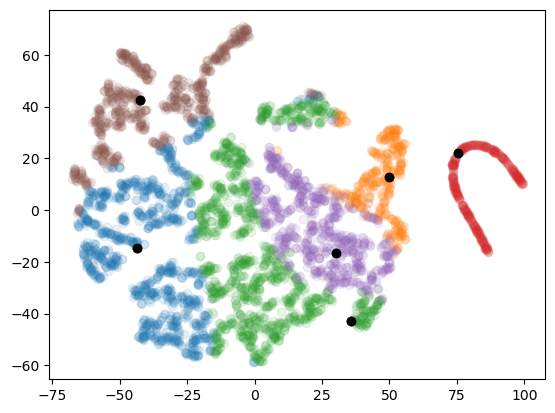

In [71]:
plt.plot(cluster_centers_reduced[:, 0], cluster_centers_reduced[:, 1], 'ko')
for id in range(processor.n_t_clusters): 
    mask = (t_space_cluster_id == id)
    plt.plot(t_space_reduced[mask, 0], t_space_reduced[mask, 1], 'o', alpha=0.1)
plt.plot(cluster_centers_reduced[:, 0], cluster_centers_reduced[:, 1], 'ko')
plt.show() 

In [72]:
processor.n_spectrum_clusters = 5

organoid_encoding, organoid_cluster_centres, cluster_id_organoids = processor.fit_spectrum_clusters() 

print(organoid_encoding.shape)

processor.random_state = 42
spectrum_reduced, organoid_cluster_centres_reduced = processor.reduce_dimensions(organoid_encoding, organoid_cluster_centres, n_components=2, method='TSNE', perplexity=30)

(341, 90)


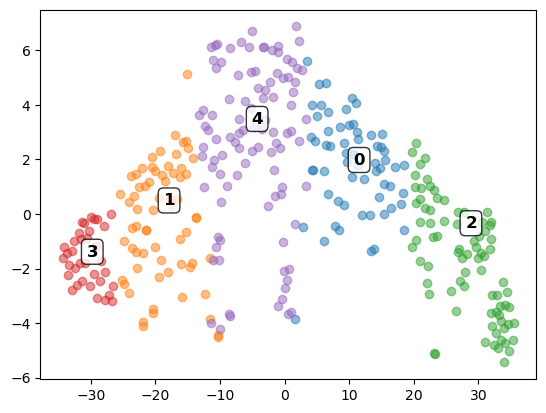

In [73]:
for id in range(processor.n_spectrum_clusters): 
    mask = (cluster_id_organoids == id)
    plt.plot(spectrum_reduced[mask, 0], spectrum_reduced[mask, 1], 'o', alpha=0.5)

# Mark cluster centers with their IDs instead of black dots
for i in range(len(organoid_cluster_centres_reduced)):
    plt.text(organoid_cluster_centres_reduced[i, 0], organoid_cluster_centres_reduced[i, 1], 
             str(i), fontsize=12, fontweight='bold', 
             bbox=dict(boxstyle="round,pad=0.3", facecolor='white', edgecolor='black', alpha=0.8))

plt.show()

['1p5' '2' '2p5' '3' '3p5' '4' '4p5']


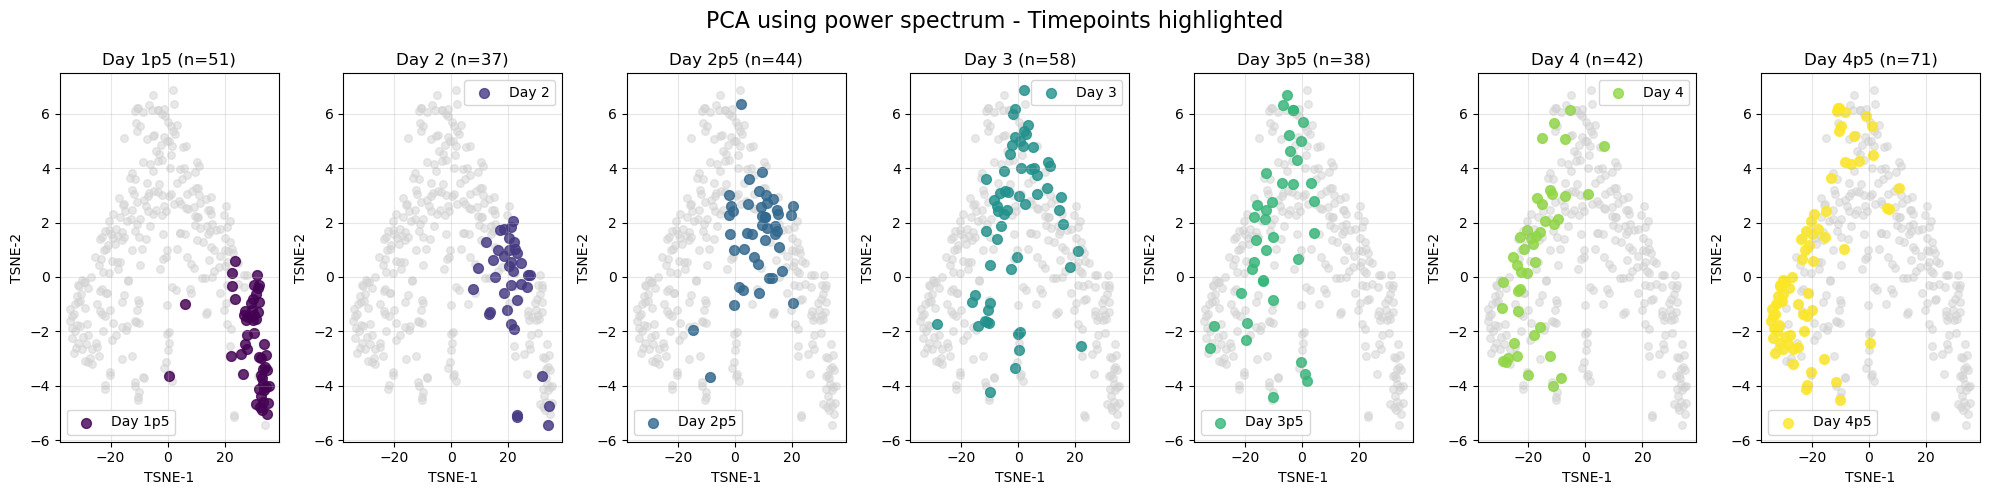

In [74]:
# Create subplots for each timepoint - spectrum PCA
unique_times = np.unique(times)

print(unique_times)
# Use a continuous colormap that represents time progression
cmap = plt.cm.viridis  # You can also try 'plasma', 'inferno', 'magma', 'cool', 'warm'
colors = [cmap(i / (len(unique_times) - 1)) for i in range(len(unique_times))]

fig, axes = plt.subplots(1, 7, figsize=(20, 5))

for i, time in enumerate(unique_times):
    ax = axes[i]
    
    # Plot all points in light gray
    ax.scatter(spectrum_reduced[:, 0], spectrum_reduced[:, 1], 
              c='lightgray', alpha=0.5, s=30)
    
    # Highlight current timepoint with color from continuous map
    times_mask = (filtered_times == time)
    ax.scatter(spectrum_reduced[:, 0][times_mask], spectrum_reduced[:, 1][times_mask], 
              c=[colors[i]], alpha=0.8, s=50, label=f'Day {time}')
    
    ax.set_xlabel('TSNE-1')
    ax.set_ylabel('TSNE-2')
    ax.set_title(f'Day {time} (n={np.sum(times_mask)})')
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.suptitle('PCA using power spectrum - Timepoints highlighted', fontsize=16)
plt.tight_layout()
plt.show()

In [75]:
orderings = [2, 0, 4, 1, 3]

dist = processor.spectrum_kmeans.transform(organoid_encoding)

# Find the closest point to each cluster center
cluster_center_ids = filtered_ids[np.argmin(dist, axis=0)[orderings]]

In [76]:
# Alternative: Enhanced meshplot with separate colorbar
from meshplot import plot

for i, id in enumerate(cluster_center_ids): 
    timepoint, well_name, label = id.split('_')
    zarr_name = zarr_names[timepoint]
    round_name = rounds[timepoint][0]
    file_path = f"{path}{timepoint}/{zarr_name}/{well_name[0]}/{well_name[1:]}/{round_name}/fm_data/{label}"
    m = FateMarkers()
    m.load_results(file_path) 

    coeffs_hks = m.compute_hks_for_new_times(new_ts=[1, 25])
    hks = m.reconstruct_from_coeffs(coeffs_hks[:])
    
    # Create the meshplot visualization
    print(np.min(hks[:, -1]), np.max(hks[:, -1]))
    plot(m.v, m.f, c=hks[:, -1])

0.04643053 0.046433397


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0013663…

0.020779328 0.0207806


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.011408…

0.009590602 0.009675633


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.110826…

0.006396628 0.0069785444


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.056982…

0.0033690727 0.0074816104


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.244634…